<a href="https://colab.research.google.com/github/jcesarmph-ui/SmartPredict/blob/main/N1_Julio_Cesar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/dados_tratados.csv')

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,False,True,False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
model = RandomForestClassifier(
    max_depth=5,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=200,
                       random_state=42)

# Parte 1 — Teste de Estresse

Nesta etapa, foram aplicadas variações artificiais nas variáveis mais importantes do modelo para analisar sua robustez e sensibilidade a ruídos nos sensores industriais.

In [8]:
X_test_ruido = X_test.copy()

# Aplicando ruído artificial de 10%
X_test_ruido['Torque [Nm]'] *= 1.10
X_test_ruido['Tool wear [min]'] *= 1.10
X_test_ruido['Process temperature [K]'] *= 1.10

y_pred_ruido = model.predict(X_test_ruido)

acc_ruido = accuracy_score(y_test, y_pred_ruido)

print("Acurácia com ruído:", acc_ruido)

Acurácia com ruído: 0.999


In [9]:
y_pred = model.predict(X_test)

erros = X_test.copy()

erros['Real'] = y_test
erros['Previsto'] = y_pred

erros_falha = erros[erros['Real'] != erros['Previsto']]

erros_falha.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M,Real,Previsto
4684,303.6,311.8,1421,44.8,101,0,0,0,0,0,False,False,True,1,0
6478,300.5,309.8,1663,29.1,145,0,0,0,0,0,False,True,False,1,0


# Investigação de Falhas

Os registros onde o modelo apresentou erro foram analisados individualmente. Em alguns casos, os dados apresentavam valores extremos ou padrões ambíguos, dificultando a classificação correta pelo modelo.

In [10]:
!pip install shap

In [11]:
import shap

In [12]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

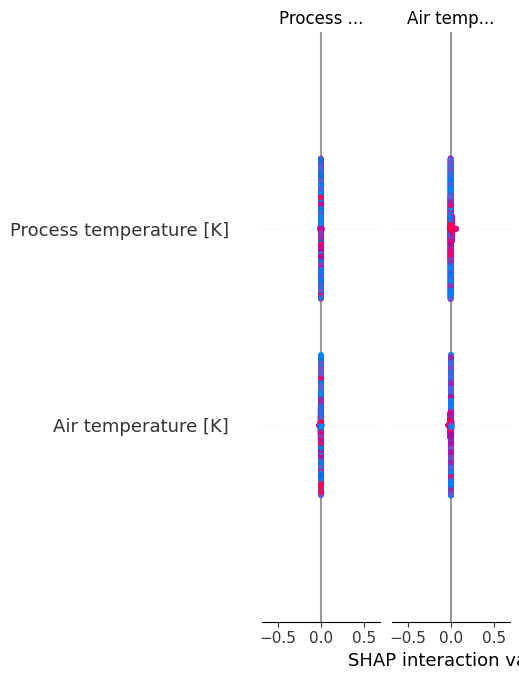

In [13]:
shap.summary_plot(shap_values, X_test)

# Interpretabilidade do Modelo

A análise com SHAP permitiu identificar quais variáveis mais influenciaram as decisões individuais da IA. Variáveis como Torque e Tool wear foram determinantes para aumentar a probabilidade de falha em máquinas industriais.

# Discussão de Viés

O modelo demonstrou maior dependência das variáveis Torque e Tool wear. Isso pode gerar sensibilidade excessiva caso os sensores apresentem ruídos ou falhas de calibração.

Além disso, como o dataset possui mais exemplos sem falha do que com falha, pode existir tendência do modelo favorecer previsões da classe majoritária.

# Plano de Ação

Para reduzir os erros encontrados, recomenda-se:

- Recalibração periódica dos sensores industriais
- Inclusão de novos dados operacionais
- Balanceamento das classes do dataset
- Treinamento contínuo do modelo com novos registros reais